In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [179]:
cmip6_members = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_cmip6_members.csv")
cmip6_mean = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_cmip6.csv")
cmip6_mean['time'] = pd.to_datetime(cmip6_mean['time'])
cmip6_mean['date'] = cmip6_mean['time']
cmip6_mean = cmip6_mean.rename(columns = {"cmip6_anomaly": "cmip6_mean"})
cmip6_means = cmip6_mean[['date', 'cmip6_mean']]

cmip6_rolling = cmip6_mean.set_index('time').rolling('3650D', center = True).mean(numeric_only=True).reset_index()
cmip6_rolling['year'] = cmip6_rolling['time'].dt.year
cmip6_rolling['month'] = cmip6_rolling['time'].dt.month
cmip6_rolling['date'] = pd.to_datetime(dict(year=cmip6_rolling['year'], month=cmip6_rolling['month'], day=1))
cmip6_rolling = cmip6_rolling[['date', 'cmip6_mean']]
cmip6_rolling = cmip6_rolling.rename(columns = {"cmip6_mean": "cmip6_10yr_rolling_mean"})

era5 = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_era5.csv")
era5['date'] = pd.to_datetime(era5['time'])
era5 = era5[['date', 'era5_anomaly']]

forecast = pd.read_csv("/home/emily_zuetell/projects/poreallas/analysis/pop_weighted_anomaly_forecast.csv")
forecast = forecast[forecast['month'].isin([8, 9, 10, 11, 12, 1])]
forecast['date'] = pd.to_datetime(forecast['time'])
forecast_wide = forecast.pivot(index='date', columns='number', values='forecast_anomaly').add_prefix('forecast_').reset_index()
forecast_mean = forecast.groupby('date', as_index=False)['forecast_anomaly'].mean()
forecast_mean = forecast_mean.rename(columns = {'forecast_anomaly': "forecast_mean"})
forecast_6mo_mean = forecast_mean.mean()

In [180]:
cmip6_members = cmip6_members[['member', 'year', 'month', 'cmip6_anomaly']]

cmip6_members['date'] = pd.to_datetime(dict(year=cmip6_members['year'], month=cmip6_members['month'], day=1))
cmip6_wide = cmip6_members.pivot(index='date', columns='member', values='cmip6_anomaly').add_prefix('cmip6_').reset_index()
cmip6_wide = cmip6_wide.set_index('date').rolling('3650D', center = True).mean(numeric_only=True).reset_index()
df_merged = era5.merge(forecast_mean, on='date', how='outer').merge(cmip6_means, on='date', how='outer').merge(cmip6_rolling, on='date', how='outer').merge(forecast_wide, on='date', how='outer').merge(forecast_mean, on='date', how='outer').merge(cmip6_wide, on='date', how='outer')

In [181]:
df_merged.to_csv('cmip_timeseries_wide.csv')

/tmp/ipykernel_4545/1424930536.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(2005, 2061, 10))


Text(0, 0.5, 'Population-weighted temperature anomaly (C)')

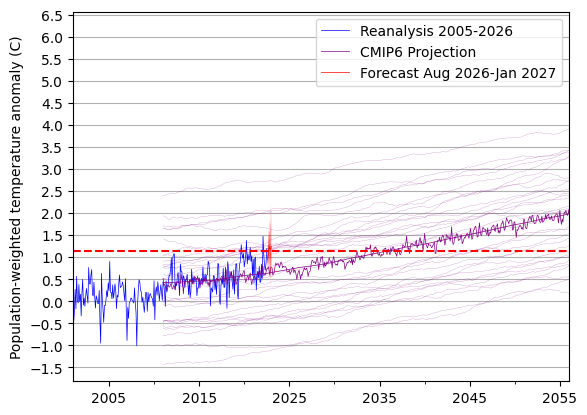

In [182]:
fig, ax = plt.subplots()
cmip6_wide.plot.line(x='date', color = 'purple', alpha = 0.5, linewidth = 0.2, ax = ax, legend = False)

era5.plot(x = 'date', y = 'era5_anomaly', linewidth = .5, color = 'blue', ax = ax, label = "Reanalysis 2005-2026")
cmip6_mean.plot(x = 'date', y = 'cmip6_mean', linewidth = .5, color = 'purple', ax = ax, legend = False)
cmip6_rolling.plot(x = 'date', y = 'cmip6_10yr_rolling_mean', linewidth = .5, color = 'purple', ax = ax, label = "CMIP6 Projection")

forecast_wide.plot.line(x='date', color = 'red', alpha = 0.1, linewidth = 0.2, ax = ax, legend = False)
forecast_mean.plot(x = 'date', y = 'forecast_mean', linewidth = .5, color = 'red', ax = ax, label = "Forecast Aug 2026-Jan 2027")
plt.axhline(forecast_6mo_mean['forecast_mean'], color = 'red', linestyle = "--")

ax.set_xticklabels(range(2005, 2061, 10))
ax.set_xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2060-01-01'))
ax.set_xlabel("")

#ax.set_ylim(-1, 2.5)
ax.grid(axis='y')
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.set_ylabel("Population-weighted temperature anomaly (C)")